In [9]:
# Stock Data Retrieval with yfinance
# This notebook retrieves closing prices for specified stock tickers between given dates

# Install required packages (uncomment if needed)
# !pip install yfinance pandas matplotlib seaborn

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def get_stock_data(tickers, start_date, end_date, save_to_csv=True, csv_filename="stock_data.csv"):
    """
    Retrieve closing prices for specified stock tickers between given dates.
    
    Parameters:
    -----------
    tickers : list
        List of stock ticker symbols (e.g., ['AAPL', 'GOOGL', 'MSFT'])
    start_date : str
        Start date in YYYY-MM-DD format
    end_date : str
        End date in YYYY-MM-DD format
    save_to_csv : bool
        Whether to save the data to a CSV file
    csv_filename : str
        Name of the CSV file to save data to
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with closing prices for each ticker
    """
    
    print(f"📊 Fetching stock data for {len(tickers)} tickers...")
    print(f"📅 Date range: {start_date} to {end_date}")
    print("-" * 50)
    
    # Convert string dates to datetime objects
    start_dt = datetime.strptime(start_date, '%Y-%m-%d')
    end_dt = datetime.strptime(end_date, '%Y-%m-%d')
    
    # Initialize empty DataFrame
    all_data = pd.DataFrame()
    failed_tickers = []
    
    for ticker in tickers:
        try:
            print(f"Fetching data for {ticker}...")
            
            # Create yfinance ticker object
            stock = yf.Ticker(ticker)
            
            # Get historical data
            hist = stock.history(start=start_date, end=end_date)
            
            if hist.empty:
                print(f"❌ No data found for {ticker}")
                failed_tickers.append(ticker)
                continue
            
            # Extract closing prices
            closing_prices = hist['Close']
            closing_prices.name = ticker
            
            # Add to main DataFrame
            if all_data.empty:
                all_data = closing_prices.to_frame()
            else:
                all_data = all_data.join(closing_prices, how='outer')
            
            print(f"✅ Successfully retrieved {len(closing_prices)} data points for {ticker}")
            
        except Exception as e:
            print(f"❌ Error fetching data for {ticker}: {str(e)}")
            failed_tickers.append(ticker)
    
    print("-" * 50)
    print(f"📈 Successfully retrieved data for {len(all_data.columns)} out of {len(tickers)} tickers")
    
    if failed_tickers:
        print(f"❌ Failed tickers: {', '.join(failed_tickers)}")
    
    # Save to CSV if requested
    if save_to_csv and not all_data.empty:
        all_data.to_csv(csv_filename)
        print(f"💾 Data saved to {csv_filename}")
    
    return all_data

def analyze_stock_data(data):
    """
    Perform basic analysis on the stock data.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame with stock closing prices
    """
    
    if data.empty:
        print("No data to analyze!")
        return
    
    print("\n" + "="*60)
    print("📊 STOCK DATA ANALYSIS")
    print("="*60)
    
    # Basic statistics
    print("\n📈 BASIC STATISTICS:")
    print("-" * 30)
    stats = data.describe()
    print(stats.round(2))
    
    # Calculate daily returns
    print("\n📉 DAILY RETURNS (%):")
    print("-" * 30)
    daily_returns = data.pct_change() * 100
    returns_stats = daily_returns.describe()
    print(returns_stats.round(2))
    
    # Calculate total returns for the period
    print("\n💰 TOTAL PERIOD RETURNS:")
    print("-" * 30)
    total_returns = ((data.iloc[-1] - data.iloc[0]) / data.iloc[0] * 100)
    total_returns_df = pd.DataFrame({
        'Start Price': data.iloc[0].round(2),
        'End Price': data.iloc[-1].round(2),
        'Total Return (%)': total_returns.round(2)
    })
    print(total_returns_df.sort_values('Total Return (%)', ascending=False))
    
    # Volatility (standard deviation of daily returns)
    print("\n📊 VOLATILITY (Daily Returns Std Dev):")
    print("-" * 30)
    volatility = daily_returns.std().sort_values(ascending=False)
    print(volatility.round(2))

def plot_stock_data(data, title="Stock Price Performance"):
    """
    Create visualizations of the stock data.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame with stock closing prices
    title : str
        Title for the plot
    """
    
    if data.empty:
        print("No data to plot!")
        return
    
    # Set up the plotting area
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # 1. Absolute price trends
    ax1 = axes[0, 0]
    for column in data.columns:
        ax1.plot(data.index, data[column], label=column, linewidth=2)
    ax1.set_title('Absolute Stock Prices')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Normalized price trends (starting at 100)
    ax2 = axes[0, 1]
    normalized_data = (data / data.iloc[0] * 100)
    for column in normalized_data.columns:
        ax2.plot(normalized_data.index, normalized_data[column], label=column, linewidth=2)
    ax2.set_title('Normalized Stock Prices (Base 100)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Normalized Price')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Daily returns distribution
    ax3 = axes[1, 0]
    daily_returns = data.pct_change() * 100
    daily_returns.boxplot(ax=ax3)
    ax3.set_title('Daily Returns Distribution')
    ax3.set_ylabel('Daily Return (%)')
    ax3.tick_params(axis='x', rotation=45)
    
    # 4. Correlation heatmap
    ax4 = axes[1, 1]
    if len(data.columns) > 1:
        correlation_matrix = data.corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                   square=True, ax=ax4, cbar_kws={'shrink': 0.8})
        ax4.set_title('Stock Price Correlations')
    else:
        ax4.text(0.5, 0.5, 'Need at least 2 stocks\nfor correlation analysis', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Correlation Analysis')
    
    plt.tight_layout()
    plt.show()

In [8]:
# !uv add matplotlib
# !uv add seaborn

🚀 STOCK DATA RETRIEVAL SYSTEM
📋 Configured Parameters:
   Tickers: AAPL, GOOGL, MSFT, AMZN, TSLA, META, NVDA, JPM, JNJ, V
   Start Date: 2024-01-01
   End Date: 2024-12-31
   Output File: stock_closing_prices.csv

📊 Fetching stock data for 10 tickers...
📅 Date range: 2024-01-01 to 2024-12-31
--------------------------------------------------
Fetching data for AAPL...
✅ Successfully retrieved 251 data points for AAPL
Fetching data for GOOGL...
✅ Successfully retrieved 251 data points for GOOGL
Fetching data for MSFT...
✅ Successfully retrieved 251 data points for MSFT
Fetching data for AMZN...
✅ Successfully retrieved 251 data points for AMZN
Fetching data for TSLA...
✅ Successfully retrieved 251 data points for TSLA
Fetching data for META...
✅ Successfully retrieved 251 data points for META
Fetching data for NVDA...
✅ Successfully retrieved 251 data points for NVDA
Fetching data for JPM...
✅ Successfully retrieved 251 data points for JPM
Fetching data for JNJ...
✅ Successfully retrieve

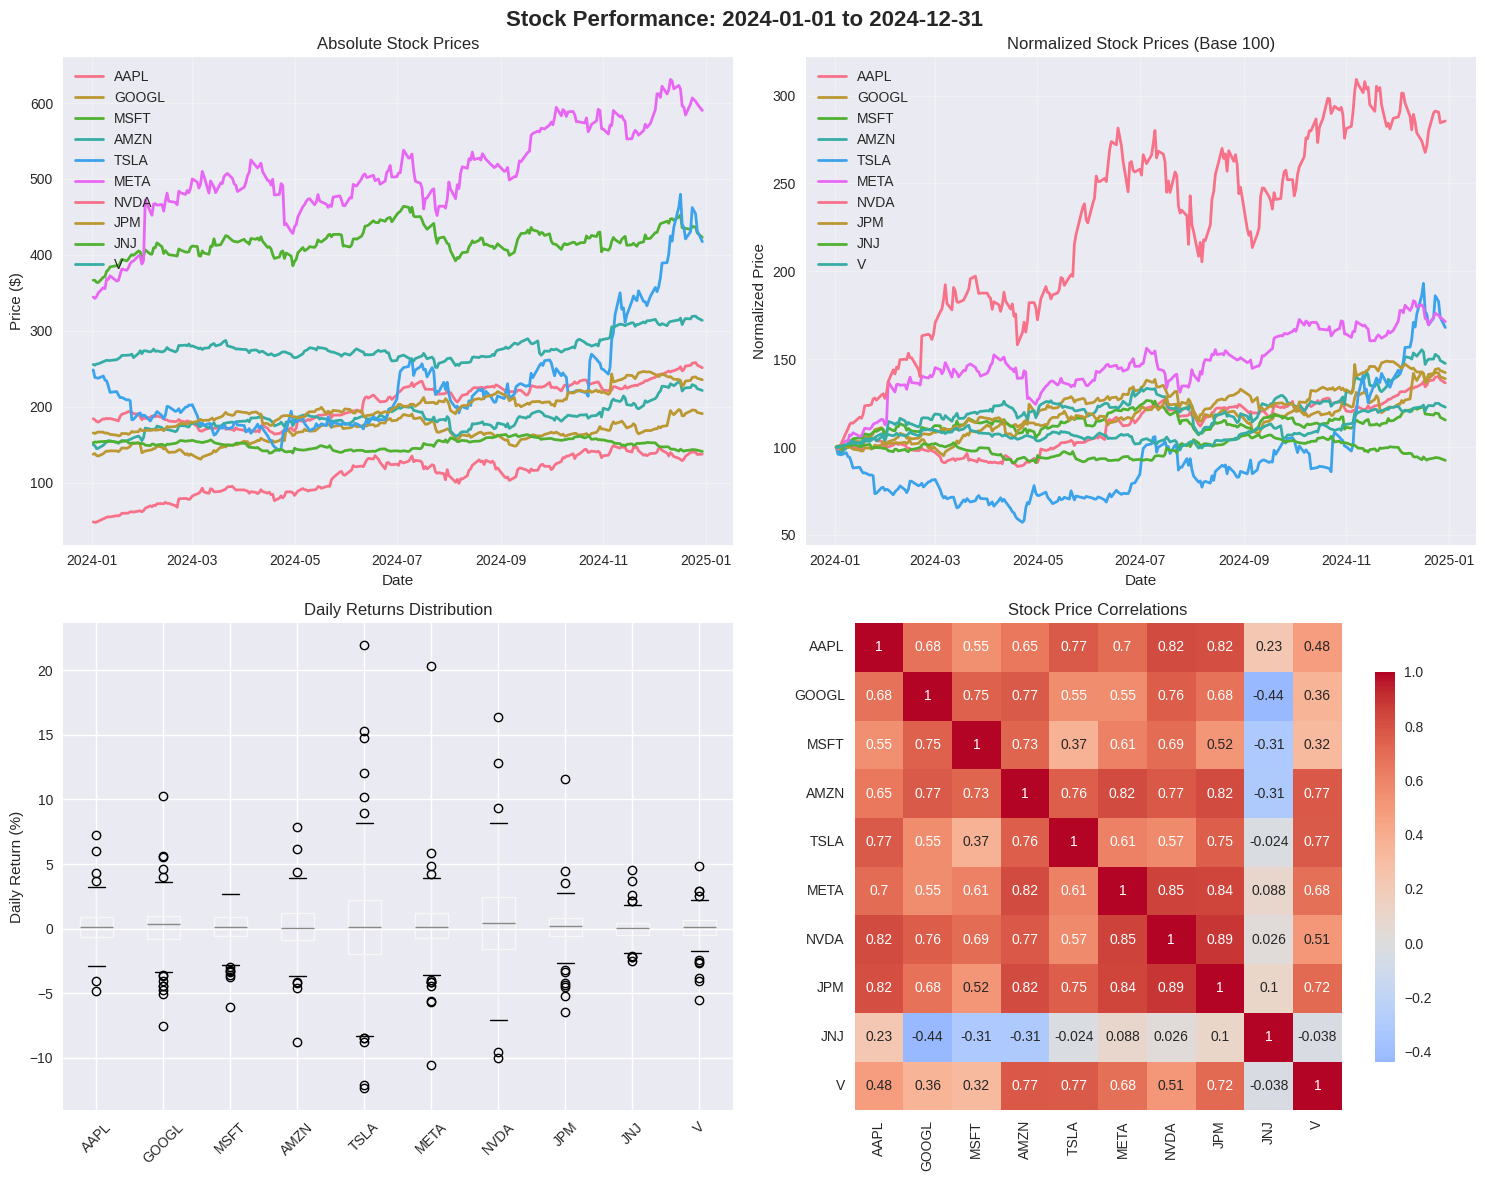


🔧 ADDITIONAL EXAMPLES

📈 Example 1: Recent AAPL data (last 7 days)
📊 Fetching stock data for 1 tickers...
📅 Date range: 2025-08-10 to 2025-08-17
--------------------------------------------------
Fetching data for AAPL...
✅ Successfully retrieved 5 data points for AAPL
--------------------------------------------------
📈 Successfully retrieved data for 1 out of 1 tickers
                                 AAPL
Date                                 
2025-08-11 00:00:00-04:00  227.179993
2025-08-12 00:00:00-04:00  229.649994
2025-08-13 00:00:00-04:00  233.330002
2025-08-14 00:00:00-04:00  232.779999
2025-08-15 00:00:00-04:00  231.589996

📊 Example 2: AAPL vs GOOGL comparison
📊 Fetching stock data for 2 tickers...
📅 Date range: 2024-01-01 to 2024-12-31
--------------------------------------------------
Fetching data for AAPL...
✅ Successfully retrieved 251 data points for AAPL
Fetching data for GOOGL...
✅ Successfully retrieved 251 data points for GOOGL
-------------------------------------

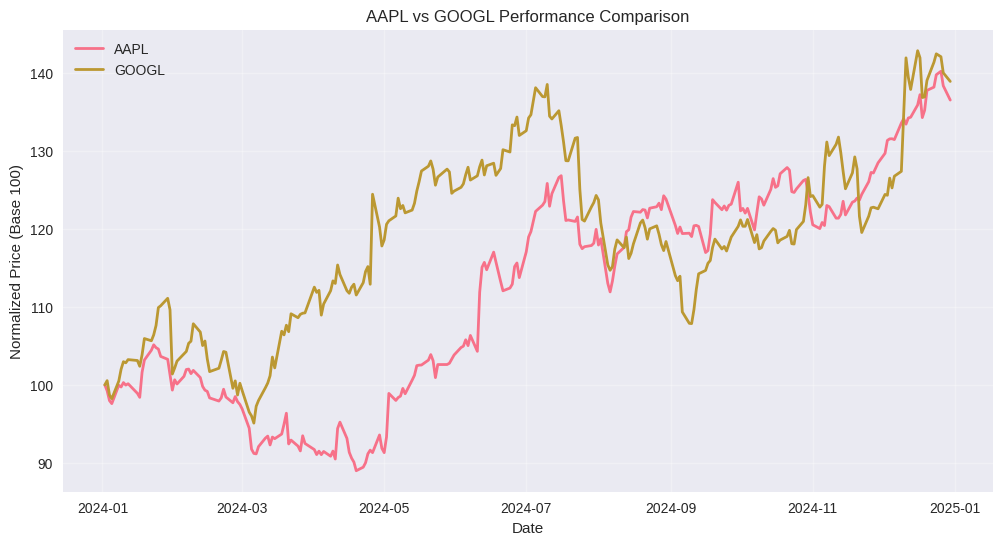


📊 PERFORMANCE COMPARISON:
AAPL: 36.52% total return
GOOGL: 38.91% total return
🏆 Winner: GOOGL

✅ Notebook execution completed!
💡 To use with different parameters, modify the INPUT PARAMETERS section and re-run the cells.


In [10]:

# =============================================================================
# MAIN EXECUTION SECTION
# =============================================================================

print("🚀 STOCK DATA RETRIEVAL SYSTEM")
print("=" * 50)

# INPUT PARAMETERS - MODIFY THESE AS NEEDED
# =============================================================================

# List of stock tickers (you can modify this list)
STOCK_TICKERS = [
    'AAPL',   # Apple Inc.
    'GOOGL',  # Alphabet Inc.
    'MSFT',   # Microsoft Corporation
    'AMZN',   # Amazon.com Inc.
    'TSLA',   # Tesla Inc.
    'META',   # Meta Platforms Inc.
    'NVDA',   # NVIDIA Corporation
    'JPM',    # JPMorgan Chase & Co.
    'JNJ',    # Johnson & Johnson
    'V'       # Visa Inc.
]

# Date range (modify as needed)
START_DATE = '2024-01-01'
END_DATE = '2024-12-31'

# CSV filename for saving data
CSV_FILENAME = 'stock_closing_prices.csv'

# =============================================================================

print(f"📋 Configured Parameters:")
print(f"   Tickers: {', '.join(STOCK_TICKERS)}")
print(f"   Start Date: {START_DATE}")
print(f"   End Date: {END_DATE}")
print(f"   Output File: {CSV_FILENAME}")
print("\n" + "="*50)

# Execute the data retrieval
stock_data = get_stock_data(
    tickers=STOCK_TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    save_to_csv=True,
    csv_filename=CSV_FILENAME
)

# Perform analysis if data was retrieved successfully
if not stock_data.empty:
    # Display first and last few rows
    print(f"\n📊 RETRIEVED DATA PREVIEW:")
    print("-" * 30)
    print("First 5 rows:")
    print(stock_data.head())
    print(f"\nLast 5 rows:")
    print(stock_data.tail())
    
    # Perform detailed analysis
    analyze_stock_data(stock_data)
    
    # Create visualizations
    plot_stock_data(stock_data, f"Stock Performance: {START_DATE} to {END_DATE}")
    
else:
    print("❌ No stock data was retrieved. Please check your parameters and try again.")

# =============================================================================
# HELPER FUNCTIONS FOR CUSTOM USE
# =============================================================================

def quick_fetch(tickers, days_back=30):
    """
    Quick function to fetch recent stock data.
    
    Parameters:
    -----------
    tickers : list or str
        Stock ticker(s) to fetch
    days_back : int
        Number of days back from today to fetch data
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with closing prices
    """
    
    if isinstance(tickers, str):
        tickers = [tickers]
    
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    
    return get_stock_data(
        tickers=tickers,
        start_date=start_date.strftime('%Y-%m-%d'),
        end_date=end_date.strftime('%Y-%m-%d'),
        save_to_csv=False
    )

def compare_stocks(ticker1, ticker2, start_date, end_date):
    """
    Compare performance of two stocks.
    
    Parameters:
    -----------
    ticker1, ticker2 : str
        Stock tickers to compare
    start_date, end_date : str
        Date range in YYYY-MM-DD format
    """
    
    data = get_stock_data([ticker1, ticker2], start_date, end_date, save_to_csv=False)
    
    if data.empty:
        return
    
    # Calculate normalized performance
    normalized = (data / data.iloc[0] * 100)
    
    plt.figure(figsize=(12, 6))
    plt.plot(normalized.index, normalized[ticker1], label=ticker1, linewidth=2)
    plt.plot(normalized.index, normalized[ticker2], label=ticker2, linewidth=2)
    plt.title(f'{ticker1} vs {ticker2} Performance Comparison')
    plt.xlabel('Date')
    plt.ylabel('Normalized Price (Base 100)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Print performance summary
    total_return_1 = (normalized[ticker1].iloc[-1] - 100)
    total_return_2 = (normalized[ticker2].iloc[-1] - 100)
    
    print(f"\n📊 PERFORMANCE COMPARISON:")
    print(f"{ticker1}: {total_return_1:.2f}% total return")
    print(f"{ticker2}: {total_return_2:.2f}% total return")
    
    winner = ticker1 if total_return_1 > total_return_2 else ticker2
    print(f"🏆 Winner: {winner}")

# =============================================================================
# EXAMPLE USAGE OF HELPER FUNCTIONS
# =============================================================================

print("\n" + "="*60)
print("🔧 ADDITIONAL EXAMPLES")
print("="*60)

# Example 1: Quick fetch recent data for a single stock
print("\n📈 Example 1: Recent AAPL data (last 7 days)")
recent_aapl = quick_fetch('AAPL', days_back=7)
if not recent_aapl.empty:
    print(recent_aapl.tail())

# Example 2: Compare two stocks
print("\n📊 Example 2: AAPL vs GOOGL comparison")
compare_stocks('AAPL', 'GOOGL', '2024-01-01', '2024-12-31')

print("\n✅ Notebook execution completed!")
print("💡 To use with different parameters, modify the INPUT PARAMETERS section and re-run the cells.")